# 04 — Customer risk proxy and RFM segmentation

Answers questions **7** and **10**, plus an inactivity/churn-risk **proxy**.
Uses the same preparation and positive-purchase definitions as notebooks 01–03.
SQL Server Raw stays the source of truth. Fresh kernel (reloads from SQL).

None of the labels below are confirmed churn. Repeat rate and monthly retention (notebook 03) are different measures from declining frequency and recency bands.

## 0. Setup and reload Raw (SELECT only)

In [1]:
from datetime import datetime
from decimal import Decimal, ROUND_HALF_UP
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyodbc

PROJECT = Path("..").resolve()
if not (PROJECT / "scripts").exists():
    PROJECT = Path(".").resolve()
TABLES = PROJECT / "outputs" / "tables"
FIGURES = PROJECT / "outputs" / "figures"
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)


def unique_output_path(path: Path) -> Path:
    """If the target exists, write a timestamped file instead of overwriting."""
    if not path.exists():
        return path
    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    return path.with_name(f"{path.stem}_{stamp}{path.suffix}")


server = r".\MSSQLSERVER02"
database = "RetailAnalytics"
driver = "ODBC Driver 18 for SQL Server"
connection_string = (
    f"DRIVER={{{driver}}};"
    f"SERVER={server};"
    f"DATABASE={database};"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;"
)

read_sql = """
SELECT
    raw_row_id, InvoiceNo, StockCode, Description, Quantity,
    InvoiceDate, UnitPrice, CustomerID, Country, source_file, loaded_at
FROM raw.online_retail;
"""

connection = pyodbc.connect(connection_string)
try:
    df_raw = pd.read_sql(read_sql, connection)
finally:
    connection.close()

df = df_raw.copy()
EXPECTED_ROWS = 541_909
assert len(df) == EXPECTED_ROWS
print("Loaded", len(df), "rows")

C:\Users\Admin\AppData\Local\Temp\ipykernel_28668\1915933047.py:47: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_raw = pd.read_sql(read_sql, connection)


Loaded 541909 rows


## 1. Same preparation as notebooks 01–03

Types, StockCode map, duplicate extras (kept), merchandise masks.

In [2]:
def penny(x) -> Decimal:
    return Decimal(str(float(x))).quantize(Decimal("0.01"), rounding=ROUND_HALF_UP)


def penny_sum(series: pd.Series) -> Decimal:
    return penny(float(series.sum())) if len(series) else Decimal("0.00")


for col in ["InvoiceNo", "StockCode", "CustomerID", "Country"]:
    df[col] = df[col].astype("string")
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
desc = df["Description"].astype("string").str.strip()
df["Description_clean"] = desc.mask(desc.eq(""), pd.NA)
df["UnitPrice"] = df["UnitPrice"].astype("float64")
df["line_value"] = df["Quantity"] * df["UnitPrice"]
df["is_c_prefix_invoice"] = df["InvoiceNo"].str.upper().str.startswith("C", na=False)

STOCKCODE_GROUP = {
    "POST": "postage_carriage",
    "DOT": "postage_carriage",
    "C2": "postage_carriage",
    "AMAZONFEE": "fees_commission",
    "CRUK": "fees_commission",
    "BANK CHARGES": "fees_commission",
    "D": "discount",
    "M": "manual_unresolved",
    "S": "samples",
    "B": "bad_debt_adjustment",
}
df["code_group"] = df["StockCode"].map(STOCKCODE_GROUP).astype("string")
df["code_group"] = df["code_group"].fillna("merchandise_candidate")
adjust_bad_debt = df["Description"].astype("string").str.contains(
    "Adjust bad debt", case=False, na=False
)
df.loc[adjust_bad_debt, "code_group"] = "bad_debt_adjustment"

BUSINESS_COLS = [
    "InvoiceNo", "StockCode", "Description", "Quantity",
    "InvoiceDate", "UnitPrice", "CustomerID", "Country",
]
g = df.groupby(BUSINESS_COLS, dropna=False, sort=False)
df["duplicate_group_size"] = g["raw_row_id"].transform("size")
df["duplicate_row_number"] = g["raw_row_id"].rank(method="first")
df["is_duplicate_extra"] = (df["duplicate_group_size"] > 1) & (df["duplicate_row_number"] > 1)

is_merch = df["code_group"] == "merchandise_candidate"
mask_sale = (
    is_merch & (df["Quantity"] > 0) & (df["UnitPrice"] > 0) & ~df["is_c_prefix_invoice"]
)
mask_neg = is_merch & (df["Quantity"] < 0) & (df["UnitPrice"] > 0)
mask_id_purchase = mask_sale & df["CustomerID"].notna()
mask_id_neg = mask_neg & df["CustomerID"].notna()

NB01_ID_GROSS = Decimal("8761066.65")
assert penny_sum(df.loc[mask_id_purchase, "line_value"]) == NB01_ID_GROSS
print("Identified-customer gross purchases:", NB01_ID_GROSS)
print(df["code_group"].value_counts())

Identified-customer gross purchases: 8761066.65
code_group
merchandise_candidate    538998
postage_carriage           2110
manual_unresolved           571
fees_commission              87
discount                     77
samples                      63
bad_debt_adjustment           3
Name: count, dtype: Int64


## 2. Purchase-level data and identified negatives

One row per `CustomerID` + `InvoiceNo` on the positive-sale mask.
Negative merchandise lines are **not** purchase events and are **not** confirmed cash refunds.
RFM snapshot date is **2011-12-10** (day after the extract maximum), matching notebook 01.

In [3]:
RFM_REF = pd.Timestamp("2011-12-10")
print("Max InvoiceDate in full extract:", df["InvoiceDate"].max())
print("RFM reference date:", RFM_REF)

eligible = df.loc[mask_id_purchase].copy()
purchases = (
    eligible.groupby(["CustomerID", "InvoiceNo"], as_index=False)
    .agg(
        purchase_timestamp=("InvoiceDate", "min"),
        gross_purchase_value=("line_value", "sum"),
        positive_units=("Quantity", "sum"),
    )
)
purchases = purchases.sort_values(
    ["CustomerID", "purchase_timestamp", "InvoiceNo"]
).reset_index(drop=True)

assert purchases.duplicated(["CustomerID", "InvoiceNo"]).sum() == 0
assert penny_sum(purchases["gross_purchase_value"]) == NB01_ID_GROSS

id_neg = (
    df.loc[mask_id_neg]
    .groupby("CustomerID", dropna=False)["line_value"]
    .sum()
    .rename("identified_negative_merchandise_value")
)

neg_only_ids = (
    set(df.loc[mask_id_neg, "CustomerID"].dropna().unique())
    - set(purchases["CustomerID"].unique())
)
print("Purchase invoices:", len(purchases))
print("Identified purchasing customers:", purchases["CustomerID"].nunique())
print("Negative-only identified customers (excluded from RFM):", len(neg_only_ids))

Max InvoiceDate in full extract: 2011-12-09 12:50:00
RFM reference date: 2011-12-10 00:00:00


Purchase invoices: 18402
Identified purchasing customers: 4334
Negative-only identified customers (excluded from RFM): 28


## 3. Customer lifetime table

Recency uses calendar dates: days from last positive purchase date to 2011-12-10.
Frequency is distinct invoices, not line counts.

In [4]:
cust = (
    purchases.groupby("CustomerID", as_index=False)
    .agg(
        last_positive_purchase=("purchase_timestamp", "max"),
        first_observed_purchase=("purchase_timestamp", "min"),
        lifetime_gross=("gross_purchase_value", "sum"),
        lifetime_invoices=("InvoiceNo", "nunique"),
        lifetime_units=("positive_units", "sum"),
    )
)
cust = cust.merge(id_neg, on="CustomerID", how="left")
cust["identified_negative_merchandise_value"] = cust[
    "identified_negative_merchandise_value"
].fillna(0.0)
cust["lifetime_net"] = (
    cust["lifetime_gross"] + cust["identified_negative_merchandise_value"]
)
cust["recency_days"] = (
    RFM_REF.normalize() - cust["last_positive_purchase"].dt.normalize()
).dt.days

assert cust["CustomerID"].is_unique
assert cust["CustomerID"].notna().all()
assert (cust["recency_days"] >= 0).all()
assert penny_sum(cust["lifetime_gross"]) == NB01_ID_GROSS
assert (cust["lifetime_invoices"] >= 1).all()
print(cust[["recency_days", "lifetime_invoices", "lifetime_gross", "lifetime_net"]].describe())

       recency_days  lifetime_invoices  lifetime_gross   lifetime_net
count   4334.000000        4334.000000     4334.000000    4334.000000
mean      93.226581           4.245962     2021.473616    1912.917929
std      100.175327           7.634989     8907.501378    8291.217430
min        1.000000           1.000000        3.750000    -141.480000
25%       18.000000           1.000000      305.560000     298.530000
50%       51.000000           2.000000      668.125000     652.405000
75%      143.000000           5.000000     1631.622500    1606.405000
max      374.000000         206.000000   279138.020000  278778.020000


## 4. Question 7 — High-value customers with declining invoice frequency

Two adjacent windows (no overlap):

- **Prior:** 2011-06-11 00:00:00 inclusive to 2011-09-10 00:00:00 exclusive (91 days).
- **Recent:** 2011-09-10 00:00:00 inclusive to 2011-12-10 00:00:00 exclusive (91 days; covers observed purchases through 2011-12-09; December is still partial).
Equal nominal window length does not remove seasonality or incomplete-month bias.

High value = lifetime gross percentile rank (`rank(method="min", pct=True)`) **≥ 0.80**. Tied values share a rank, so the 80% cut does not split a tie. `qcut` is shown only as a comparison.

A **declining-frequency candidate** is high value, with at least 2 prior-window invoices, and fewer recent-window invoices than prior. This is a re-engagement list, not confirmed churn.

In [5]:
PRIOR_START = pd.Timestamp("2011-06-11")
PRIOR_END = pd.Timestamp("2011-09-10")
RECENT_START = pd.Timestamp("2011-09-10")
RECENT_END = pd.Timestamp("2011-12-10")
assert PRIOR_END == RECENT_START
assert PRIOR_END - PRIOR_START == RECENT_END - RECENT_START

ts = purchases["purchase_timestamp"]
in_prior = (ts >= PRIOR_START) & (ts < PRIOR_END)
in_recent = (ts >= RECENT_START) & (ts < RECENT_END)
assert not (in_prior & in_recent).any()
print("Prior window calendar days:", (PRIOR_END - PRIOR_START).days)
print("Recent window calendar days:", (RECENT_END - RECENT_START).days)
print("Prior invoices:", int(in_prior.sum()), "Recent invoices:", int(in_recent.sum()))
print("Recent max timestamp:", purchases.loc[in_recent, "purchase_timestamp"].max())

def window_stats(mask, prefix):
    w = (
        purchases.loc[mask]
        .groupby("CustomerID", as_index=False)
        .agg(
            **{
                f"{prefix}_invoices": ("InvoiceNo", "nunique"),
                f"{prefix}_gross": ("gross_purchase_value", "sum"),
            }
        )
    )
    return w

cust = cust.merge(window_stats(in_prior, "prior"), on="CustomerID", how="left")
cust = cust.merge(window_stats(in_recent, "recent"), on="CustomerID", how="left")
cust["prior_invoices"] = cust["prior_invoices"].fillna(0).astype(int)
cust["recent_invoices"] = cust["recent_invoices"].fillna(0).astype(int)
cust["prior_gross"] = cust["prior_gross"].fillna(0.0)
cust["recent_gross"] = cust["recent_gross"].fillna(0.0)
cust["invoice_frequency_change"] = cust["recent_invoices"] - cust["prior_invoices"]
cust["gross_value_change"] = cust["recent_gross"] - cust["prior_gross"]
cust["gross_value_pct_change"] = np.where(
    cust["prior_gross"] > 0,
    cust["gross_value_change"] / cust["prior_gross"] * 100,
    pd.NA,
)

Prior window calendar days: 91
Recent window calendar days: 91
Prior invoices: 3942 Recent invoices: 6575
Recent max timestamp: 2011-12-09 12:50:00


In [6]:
# Stable high-value flag: min-rank percentile. Do not use qcut for the flag.
cust["gross_pct_rank"] = cust["lifetime_gross"].rank(method="min", pct=True)
cust["is_high_value"] = (cust["gross_pct_rank"] >= 0.80).astype(bool)

# Learning comparison only: qcut can drop bins or split ties.
qcut_compare = pd.qcut(
    cust["lifetime_gross"], 5, labels=False, duplicates="drop"
)
print("qcut unique bins (comparison only, not used):", qcut_compare.nunique())
print(
    "High-value customers (pct rank >= 0.80):",
    int(cust["is_high_value"].sum()),
    "share",
    float(cust["is_high_value"].mean()),
)

cust["is_declining_frequency_candidate"] = (
    cust["is_high_value"]
    & (cust["prior_invoices"] >= 2)
    & (cust["recent_invoices"] < cust["prior_invoices"])
).astype(bool)
cust["no_recent_window_purchases"] = (cust["recent_invoices"] == 0).astype(bool)
cust["recent_gross_down_50pct"] = (
    (cust["prior_gross"] > 0)
    & (cust["recent_gross"] <= 0.5 * cust["prior_gross"])
).astype(bool)

cand = cust.loc[cust["is_declining_frequency_candidate"]].copy()
print("Declining-frequency candidates:", len(cand))
print("  lifetime gross pennies:", penny_sum(cand["lifetime_gross"]))
print("  lifetime net pennies:", penny_sum(cand["lifetime_net"]))
print("  no recent purchases among candidates:", int(cand["no_recent_window_purchases"].sum()))
print("  recent gross down >=50% among candidates:", int(cand["recent_gross_down_50pct"].sum()))

top20 = cand.sort_values(["lifetime_gross", "CustomerID"], ascending=[False, True]).head(20)
print("\nTop 20 candidates by lifetime gross:")
print(
    top20[
        [
            "CustomerID",
            "lifetime_gross",
            "lifetime_net",
            "lifetime_invoices",
            "prior_invoices",
            "recent_invoices",
            "invoice_frequency_change",
            "prior_gross",
            "recent_gross",
            "recency_days",
        ]
    ].to_string(index=False)
)

qcut unique bins (comparison only, not used): 5
High-value customers (pct rank >= 0.80): 867 share 0.20004614674665436
Declining-frequency candidates: 192
  lifetime gross pennies: 1367496.97
  lifetime net pennies: 1325106.33
  no recent purchases among candidates: 24
  recent gross down >=50% among candidates: 98

Top 20 candidates by lifetime gross:
CustomerID  lifetime_gross  lifetime_net  lifetime_invoices  prior_invoices  recent_invoices  invoice_frequency_change  prior_gross  recent_gross  recency_days
     12415       124564.53     123638.18                 20               8                6                        -2     51203.98      22826.65            25
     14156       116729.63     113855.32                 54              22               13                        -9     53692.99      18321.29            10
     16029        72882.09      58193.85                 62              21               11                       -10     17557.88      26720.70            39
     

Saved D:\Python Projects\retail-transaction-analytics\outputs\figures\reengagement_candidates_top20_20260901_234359.png


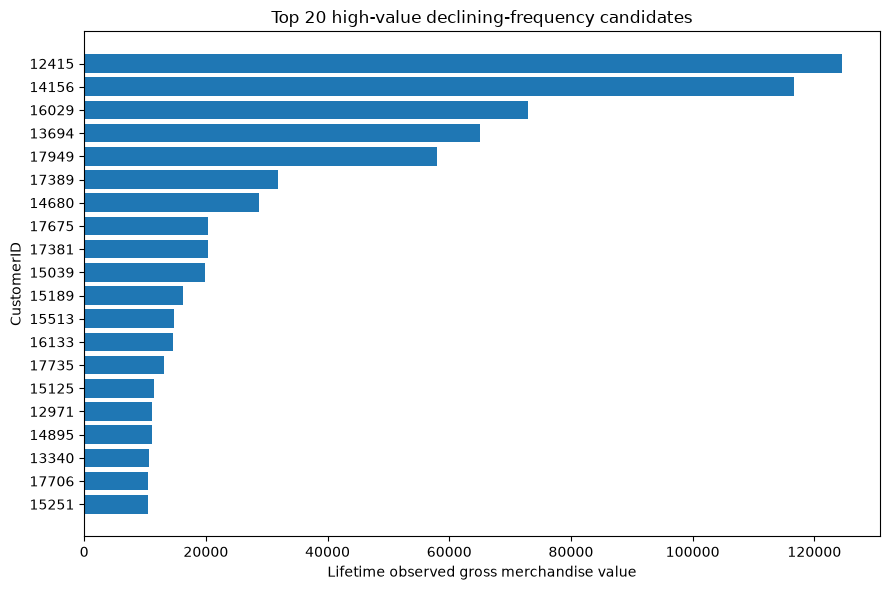

In [7]:
fig, ax = plt.subplots(figsize=(9, 6))
plot20 = top20.sort_values("lifetime_gross")
labels = plot20["CustomerID"].astype(str)
ax.barh(range(len(plot20)), plot20["lifetime_gross"])
ax.set_yticks(range(len(plot20)), labels)
ax.set_xlabel("Lifetime observed gross merchandise value")
ax.set_ylabel("CustomerID")
ax.set_title("Top 20 high-value declining-frequency candidates")
fig.tight_layout()
p = unique_output_path(FIGURES / "reengagement_candidates_top20.png")
fig.savefig(p, dpi=120)
print("Saved", p)
plt.show()

## 5. Inactivity / churn-risk proxy

Project bands as at **2011-12-10**. These are recency assumptions, **not** observed churn events and **not** an official churn rate.

- Active: 0–30 days
- Cooling: 31–60 days
- At Risk: 61–90 days
- Inactive: over 90 days

In [8]:
band_rules = [
    (cust["recency_days"] <= 30, "Active"),
    (cust["recency_days"].between(31, 60), "Cooling"),
    (cust["recency_days"].between(61, 90), "At Risk"),
    (cust["recency_days"] > 90, "Inactive"),
]
print("Inactivity band rules (first match wins):")
print("  Active: recency_days <= 30")
print("  Cooling: 31 <= recency_days <= 60")
print("  At Risk: 61 <= recency_days <= 90")
print("  Inactive: recency_days > 90")

cust["inactivity_band"] = np.select(
    [r[0] for r in band_rules],
    [r[1] for r in band_rules],
    default=None,
)
assert cust["inactivity_band"].notna().all()
assert cust["inactivity_band"].nunique() <= 4

band_order = ["Active", "Cooling", "At Risk", "Inactive"]
band_summary = (
    cust.groupby("inactivity_band", as_index=False)
    .agg(
        customers=("CustomerID", "nunique"),
        lifetime_gross=("lifetime_gross", "sum"),
        lifetime_net=("lifetime_net", "sum"),
        avg_invoices=("lifetime_invoices", "mean"),
        avg_recency=("recency_days", "mean"),
    )
)
band_summary["inactivity_band"] = pd.Categorical(
    band_summary["inactivity_band"], categories=band_order, ordered=True
)
band_summary = band_summary.sort_values("inactivity_band")
band_summary["customer_share_pct"] = (
    band_summary["customers"] / band_summary["customers"].sum() * 100
)
assert int(band_summary["customers"].sum()) == len(cust)
print(band_summary.to_string(index=False))

Inactivity band rules (first match wins):
  Active: recency_days <= 30
  Cooling: 31 <= recency_days <= 60
  At Risk: 61 <= recency_days <= 90
  Inactive: recency_days > 90
inactivity_band  customers  lifetime_gross  lifetime_net  avg_invoices  avg_recency  customer_share_pct
         Active       1627     6152422.560   5846925.510      7.276583    13.808851           37.540378
        Cooling        747     1057837.231   1025685.071      3.431058    44.267738           17.235810
        At Risk        511      531367.351    520126.191      2.610568    73.861057           11.790494
       Inactive       1449     1019439.511    897849.531      1.839890   214.469289           33.433318


Saved D:\Python Projects\retail-transaction-analytics\outputs\figures\inactivity_band_counts_20260901_234359.png


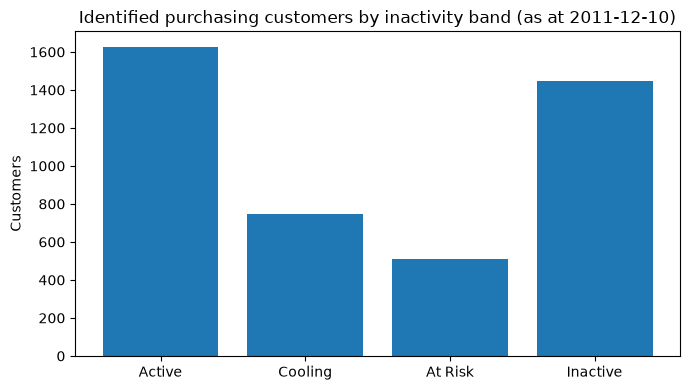

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
b = band_summary.set_index("inactivity_band").loc[band_order]
ax.bar(b.index.astype(str), b["customers"])
ax.set_ylabel("Customers")
ax.set_title("Identified purchasing customers by inactivity band (as at 2011-12-10)")
fig.tight_layout()
p = unique_output_path(FIGURES / "inactivity_band_counts.png")
fig.savefig(p, dpi=120)
print("Saved", p)
plt.show()

## 6. Question 10 — RFM scores

One row per identified **purchasing** customer (negative-only IDs are excluded).

- **R:** calendar days from last positive purchase to 2011-12-10 (lower is better → score 5).
- **F:** distinct positive purchase invoices (higher is better → score 5).
- **M:** lifetime observed **gross** merchandise value (higher is better → score 5). Net is diagnostic only.

Scores use `rank(method="min", pct=True)` then `ceil(pct * 5)` clipped to 1–5.
Equal Frequency values get the same F score; ties are not split to force equal group sizes.

In [10]:
def score_high_is_better(series: pd.Series) -> pd.Series:
    pct = series.rank(method="min", pct=True, ascending=True)
    return np.ceil(pct * 5).clip(1, 5).astype(int)


def score_low_is_better(series: pd.Series) -> pd.Series:
    pct = series.rank(method="min", pct=True, ascending=False)
    return np.ceil(pct * 5).clip(1, 5).astype(int)


cust["R"] = score_low_is_better(cust["recency_days"])
cust["F"] = score_high_is_better(cust["lifetime_invoices"])
cust["M"] = score_high_is_better(cust["lifetime_gross"])

assert cust["R"].between(1, 5).all()
assert cust["F"].between(1, 5).all()
assert cust["M"].between(1, 5).all()
assert (cust.groupby("lifetime_invoices")["F"].nunique() == 1).all()

# qcut on F is comparison only (often unstable with discrete ties).
f_qcut = pd.qcut(cust["lifetime_invoices"], 5, duplicates="drop")
print("F qcut bins (comparison only):", f_qcut.nunique(), "categories")
print(f_qcut.value_counts().sort_index())


def score_ranges(score_col, metric_col, label):
    g = cust.groupby(score_col).agg(
        customers=("CustomerID", "size"),
        metric_min=(metric_col, "min"),
        metric_max=(metric_col, "max"),
    )
    print(f"\n{label} score vs {metric_col}:")
    print(g.to_string())


score_ranges("R", "recency_days", "R")
score_ranges("F", "lifetime_invoices", "F")
score_ranges("M", "lifetime_gross", "M")

cust["RFM_code"] = (
    cust["R"].astype(str) + cust["F"].astype(str) + cust["M"].astype(str)
)
cust["RFM_total"] = cust["R"] + cust["F"] + cust["M"]

F qcut bins (comparison only): 4 categories
lifetime_invoices
(0.999, 2.0]    2336
(2.0, 3.0]       502
(3.0, 5.0]       631
(5.0, 206.0]     865
Name: count, dtype: int64

R score vs recency_days:
   customers  metric_min  metric_max
R                                   
1        871         180         374
2        884          72         179
3        867          33          71
4        847          15          32
5        865           1          13

F score vs lifetime_invoices:
   customers  metric_min  metric_max
F                                   
1       1505           1           1
2        831           2           2
3        502           3           3
4        631           4           5
5        865           6         206

M score vs lifetime_gross:
   customers  metric_min  metric_max
M                                   
1        866        3.75      248.10
2        867      248.42      484.38
3        867      484.82      924.85
4        867      925.35     2043.23
5  

## 7. RFM segments (project-specific rules)

These names are **not** universal industry standards. They are mutually exclusive labels with **first-match** precedence via `np.select`.

In [11]:
print("""Exact Boolean rules (first true wins):
1. Champions:           R >= 4 and F >= 4 and M >= 4
2. Cannot Lose Them:    R <= 2 and M >= 4 and F >= 3
3. Loyal Customers:     F >= 4 and R >= 3
4. At Risk:             R <= 2 and F >= 3
5. Recent Low-Frequency: R >= 4 and F <= 2
6. Potential Loyalists: R >= 3 and F >= 2 and M >= 3
7. Hibernating:         R <= 2 and F <= 2
8. Others:              remainder
""")

R, F, M = cust["R"], cust["F"], cust["M"]
segment_conditions = [
    (R >= 4) & (F >= 4) & (M >= 4),
    (R <= 2) & (M >= 4) & (F >= 3),
    (F >= 4) & (R >= 3),
    (R <= 2) & (F >= 3),
    (R >= 4) & (F <= 2),
    (R >= 3) & (F >= 2) & (M >= 3),
    (R <= 2) & (F <= 2),
]
segment_names = [
    "Champions",
    "Cannot Lose Them",
    "Loyal Customers",
    "At Risk",
    "Recent Low-Frequency",
    "Potential Loyalists",
    "Hibernating",
]
cust["rfm_segment"] = np.select(segment_conditions, segment_names, default="Others")
assert cust["rfm_segment"].notna().all()
assert cust.groupby("CustomerID")["rfm_segment"].nunique().max() == 1

seg = (
    cust.groupby("rfm_segment", as_index=False)
    .agg(
        customers=("CustomerID", "nunique"),
        lifetime_gross=("lifetime_gross", "sum"),
        lifetime_net=("lifetime_net", "sum"),
        avg_recency=("recency_days", "mean"),
        avg_frequency=("lifetime_invoices", "mean"),
        avg_monetary=("lifetime_gross", "mean"),
    )
)
seg["customer_share_pct"] = seg["customers"] / seg["customers"].sum() * 100
seg = seg.sort_values("lifetime_gross", ascending=False)
assert int(seg["customers"].sum()) == len(cust)
print(seg.to_string(index=False))

Exact Boolean rules (first true wins):
1. Champions:           R >= 4 and F >= 4 and M >= 4
2. Cannot Lose Them:    R <= 2 and M >= 4 and F >= 3
3. Loyal Customers:     F >= 4 and R >= 3
4. At Risk:             R <= 2 and F >= 3
5. Recent Low-Frequency: R >= 4 and F <= 2
6. Potential Loyalists: R >= 3 and F >= 2 and M >= 3
7. Hibernating:         R <= 2 and F <= 2
8. Others:              remainder

         rfm_segment  customers  lifetime_gross  lifetime_net  avg_recency  avg_frequency  avg_monetary  customer_share_pct
           Champions        891     5561110.660   5430441.590    12.500561      11.551066   6241.426105           20.558376
     Loyal Customers        391      831458.451    803727.781    38.636829       5.780051   2126.492202            9.021689
         Hibernating       1354      685692.812    593497.262   208.019202       1.276957    506.420097           31.241347
    Cannot Lose Them        229      565110.030    532125.290   123.882096       4.877729   2467.72938

Saved D:\Python Projects\retail-transaction-analytics\outputs\figures\rfm_segment_counts_20260901_234400.png


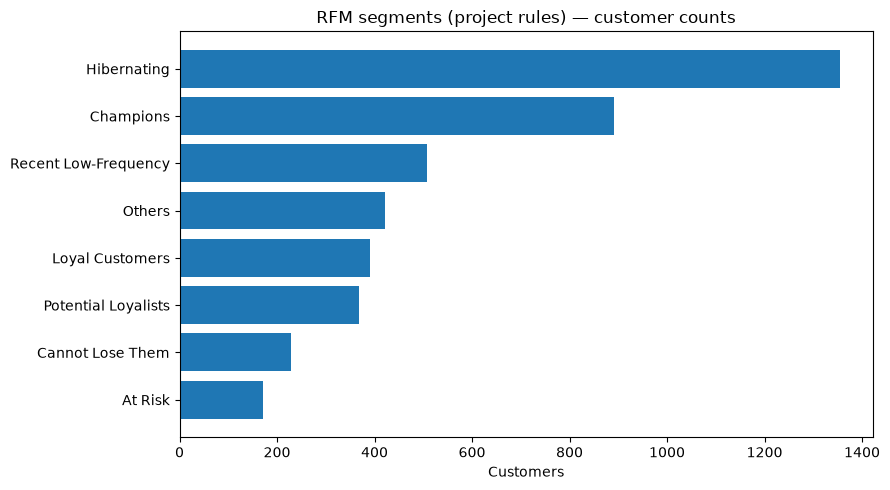

Saved D:\Python Projects\retail-transaction-analytics\outputs\figures\rfm_segment_gross_20260901_234400.png


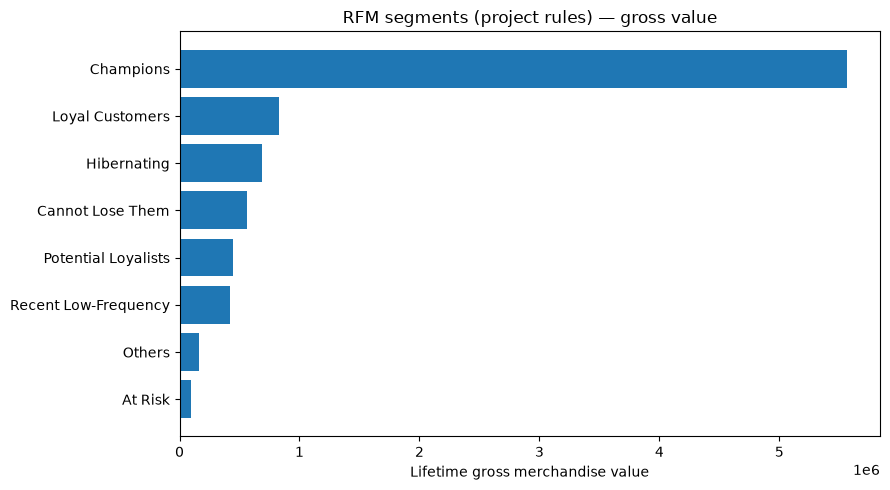

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
seg_plot = seg.sort_values("customers")
ax.barh(seg_plot["rfm_segment"], seg_plot["customers"])
ax.set_xlabel("Customers")
ax.set_title("RFM segments (project rules) — customer counts")
fig.tight_layout()
p = unique_output_path(FIGURES / "rfm_segment_counts.png")
fig.savefig(p, dpi=120)
print("Saved", p)
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
seg_val = seg.sort_values("lifetime_gross")
ax.barh(seg_val["rfm_segment"], seg_val["lifetime_gross"])
ax.set_xlabel("Lifetime gross merchandise value")
ax.set_title("RFM segments (project rules) — gross value")
fig.tight_layout()
p = unique_output_path(FIGURES / "rfm_segment_gross.png")
fig.savefig(p, dpi=120)
print("Saved", p)
plt.show()

Saved D:\Python Projects\retail-transaction-analytics\outputs\figures\rfm_recency_frequency_scatter_20260901_234401.png


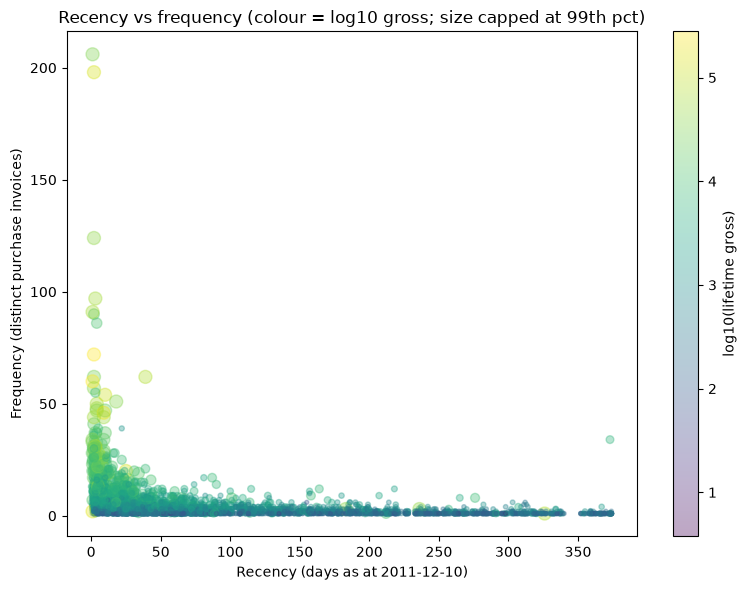

In [13]:
# Scatter is display-only. Colour uses log10(gross); size is capped at the 99th percentile
# so a few very large customers do not hide the rest. cust is not modified.
display = cust.copy()
display["log10_gross"] = np.log10(display["lifetime_gross"].clip(lower=1))
size_cap = display["lifetime_gross"].quantile(0.99)
display["point_size"] = display["lifetime_gross"].clip(upper=size_cap) / size_cap * 80 + 8

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    display["recency_days"],
    display["lifetime_invoices"],
    c=display["log10_gross"],
    s=display["point_size"],
    alpha=0.35,
    cmap="viridis",
)
ax.set_xlabel("Recency (days as at 2011-12-10)")
ax.set_ylabel("Frequency (distinct purchase invoices)")
ax.set_title("Recency vs frequency (colour = log10 gross; size capped at 99th pct)")
fig.colorbar(sc, ax=ax, label="log10(lifetime gross)")
fig.tight_layout()
p = unique_output_path(FIGURES / "rfm_recency_frequency_scatter.png")
fig.savefig(p, dpi=120)
print("Saved", p)
plt.show()

## 8. Validation

In [14]:
assert len(cust) == purchases["CustomerID"].nunique()
assert cust["CustomerID"].is_unique
assert cust["CustomerID"].notna().all()
assert penny_sum(cust["lifetime_gross"]) == NB01_ID_GROSS
assert (cust["lifetime_invoices"] == cust["lifetime_invoices"]).all()
inv_check = purchases.groupby("CustomerID")["InvoiceNo"].nunique()
assert (cust.set_index("CustomerID")["lifetime_invoices"] == inv_check).all()
assert (cust["recency_days"] >= 0).all()
assert not (in_prior & in_recent).any()
for col in [
    "is_high_value",
    "is_declining_frequency_candidate",
    "no_recent_window_purchases",
    "recent_gross_down_50pct",
]:
    assert cust[col].dtype == bool
assert cust["R"].between(1, 5).all() and pd.api.types.is_integer_dtype(cust["R"])
assert cust["F"].between(1, 5).all() and pd.api.types.is_integer_dtype(cust["F"])
assert cust["M"].between(1, 5).all() and pd.api.types.is_integer_dtype(cust["M"])
assert (cust.groupby("lifetime_invoices")["F"].nunique() == 1).all()
assert int(seg["customers"].sum()) == len(cust)
assert int(band_summary["customers"].sum()) == len(cust)
print("Negative-only identified customers excluded from RFM:", len(neg_only_ids))
print("All RFM / risk assertions passed.")

Negative-only identified customers excluded from RFM: 28
All RFM / risk assertions passed.


## 9. Save tables (non-overwriting)

In [15]:
trend_cols = [
    "CustomerID",
    "lifetime_gross",
    "lifetime_invoices",
    "lifetime_net",
    "identified_negative_merchandise_value",
    "prior_invoices",
    "recent_invoices",
    "prior_gross",
    "recent_gross",
    "invoice_frequency_change",
    "gross_value_change",
    "gross_value_pct_change",
    "recency_days",
    "gross_pct_rank",
    "is_high_value",
    "is_declining_frequency_candidate",
    "no_recent_window_purchases",
    "recent_gross_down_50pct",
]
rfm_cols = [
    "CustomerID",
    "recency_days",
    "lifetime_invoices",
    "lifetime_gross",
    "lifetime_net",
    "R",
    "F",
    "M",
    "RFM_code",
    "RFM_total",
    "rfm_segment",
    "inactivity_band",
    "last_positive_purchase",
    "first_observed_purchase",
]

paths = {
    "customer_frequency_trend.csv": cust[trend_cols],
    "reengagement_candidates.csv": cand.sort_values(
        ["lifetime_gross", "CustomerID"], ascending=[False, True]
    )[trend_cols],
    "customer_inactivity_bands.csv": band_summary,
    "customer_rfm.csv": cust[rfm_cols],
    "rfm_segment_summary.csv": seg,
}
for name, frame in paths.items():
    out = unique_output_path(TABLES / name)
    frame.to_csv(out, index=False)
    print("Saved", out)

Saved D:\Python Projects\retail-transaction-analytics\outputs\tables\customer_frequency_trend_20260901_234401.csv
Saved D:\Python Projects\retail-transaction-analytics\outputs\tables\reengagement_candidates_20260901_234401.csv
Saved D:\Python Projects\retail-transaction-analytics\outputs\tables\customer_inactivity_bands_20260901_234401.csv


Saved D:\Python Projects\retail-transaction-analytics\outputs\tables\customer_rfm_20260901_234401.csv
Saved D:\Python Projects\retail-transaction-analytics\outputs\tables\rfm_segment_summary_20260901_234402.csv


## 10. Findings

Figures are from this executed notebook. Identified-customer gross merchandise sales reconcile to **8,761,066.65**. RFM and risk tables cover **4,334** purchasing customers. **28** negative-only identified customers are excluded from RFM and are not treated as purchasers.

**Repeat rate** (notebook 03) is whether a customer has a second invoice. **Monthly retention** is whether a cohort is active in a later calendar month. **Declining frequency** compares invoice counts in two equal 91-day windows. **Inactivity bands** are recency as at 2011-12-10. None of these is **confirmed churn**.

### Question 7 — High-value declining frequency

- High value (`rank(method="min", pct=True)` ≥ 0.80): **867** customers (**20.00%**). Declining-frequency candidates: **192** (prior invoices ≥ 2 and fewer recent invoices). Their lifetime gross is **1,367,496.97** and lifetime net **1,325,106.33**.
- Among those 192, **24** have **no** recent-window purchases and **98** have recent gross at least **50%** below prior gross (where prior gross > 0). They are **re-engagement / declining-frequency candidates**, not confirmed churned customers.
- Largest candidates by lifetime gross: **12415** (**124,564.53** gross, invoices **8 → 6**), **14156** (**116,729.63**, **22 → 13**), and **16029** (**72,882.09**, **21 → 11**).

Both windows are **91** days (prior 2011-06-11 to 2011-09-10 exclusive; recent 2011-09-10 to 2011-12-10 exclusive). Equal length does not remove seasonality or the partial December 2011 month inside the recent window (last observed timestamp **2011-12-09 12:50:00**).

### Inactivity / churn-risk proxy (as at 2011-12-10)

- **Active** (0–30 days): **1,627** customers (**37.54%**), lifetime gross **6,152,422.56**, mean recency **13.8** days, mean invoices **7.28**.
- **Inactive** (>90 days): **1,449** customers (**33.43%**), lifetime gross **1,019,439.51**, mean recency **214.5** days, mean invoices **1.84**.
- **Cooling** 31–60: **747** (**17.24%**), gross **1,057,837.23**. **At Risk** 61–90: **511** (**11.79%**), gross **531,367.35**. These bands are project assumptions, not an official churn rate.

### Question 10 — RFM segments (project rules)

- **Champions** (R≥4, F≥4, M≥4): **891** customers (**20.56%**) and **5,561,110.66** gross (**63.48%** of identified gross). Mean recency **12.5** days, mean invoices **11.55**.
- **Hibernating** (R≤2, F≤2): **1,354** customers (**31.24%**) but only **685,692.81** gross. **Cannot Lose Them** (stale, high M): **229** customers, **565,110.03** gross, mean recency **123.9** days.
- **Recent Low-Frequency** (R≥4 and F≤2): **507** customers (**11.70%**), gross **417,172.38**. High recency and low frequency do **not** prove the customer is new to the business.
- F scores do not split tied invoice counts (all F=1 customers have exactly **1** invoice). `qcut` on frequency produced **4** bins, not 5, which is why it is not used for final scores.

### Proposed next actions (not proven causes)

- Review the 192 declining-frequency high-value accounts, especially the 24 with no recent-window invoices.
- Treat Inactive and Cannot Lose Them as outreach **candidates**, not as lost customers, until a later extract shows whether they return.
- Keep Champions’ recent activity in view; do not infer that high recent share will continue after December 2011.

### Limitations

- Left-censoring and a short window; duplicate extras remain in the baseline; unidentified customers are excluded; negative merchandise is signed diagnostic value, not confirmed refunds; December 2011 is partial inside the recent window even though both windows are 91 days.
